Opening file selector...
Selected: C:/Users/kanha/Downloads/elegant-classic-car-with-retro-color-photo.jpg
Initializing model on cpu...
Running depth inference...


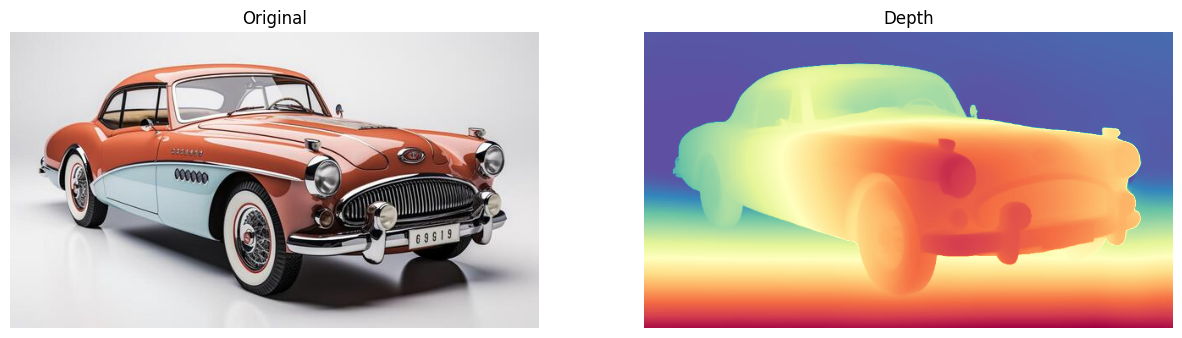

Saving depth heatmap...
Heatmap successfully saved to: C:\Users\kanha\Documents\MachLeData\src\data\DAoutputs\depth_heatmap.png
Generating 3D point cloud for viewing...
Launching interactive 3D viewer...
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 


In [5]:
import sys
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import tkinter as tk
from tkinter import filedialog
from PIL import Image

# ==========================================================
# 1. PATH SETUP (AUTOMATIC)
# ==========================================================
# Get project root assuming notebook is in 'notebooks/'
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
REPO_PATH = os.path.join(BASE_DIR, 'src', 'models', 'Depth-Anything-V2')

if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)

from depth_anything_v2.dpt import DepthAnythingV2

# ==========================================================
# 2. FILE SELECTION FUNCTION
# ==========================================================
def select_image_file():
    """Opens a Windows File Explorer dialog to pick an image."""
    root = tk.Tk()
    root.withdraw()      # Hide the tiny main tkinter window
    root.attributes("-topmost", True) # Bring the dialog to the front
    
    file_path = filedialog.askopenfilename(
        title="Select an Image for 3D Conversion",
        filetypes=[("Image Files", "*.jpg *.jpeg *.png *.bmp *.webp"), ("All Files", "*.*")]
    )
    
    root.destroy()       # Clean up tkinter
    return file_path

# ==========================================================
# 3. UTILITY FUNCTIONS
# ==========================================================
def create_and_view_point_cloud(depth, image):
    h, w = depth.shape
    fx = fy = 500  # Focal length approximation
    cx, cy = w / 2, h / 2

    x = np.arange(0, w)
    y = np.arange(0, h)
    xx, yy = np.meshgrid(x, y)
    
    z = depth / 255.0
    valid_mask = z > 0
    
    X = (xx - cx) * z / fx
    Y = (yy - cy) * z / fy
    Z = z

    points = np.stack([X, Y, Z], axis=-1)[valid_mask]
    colors = (image / 255.0)[valid_mask]

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.colors = o3d.utility.Vector3dVector(colors)
    return pcd

# ==========================================================
# 4. MAIN EXECUTION PIPELINE
# ==========================================================
def main():
    # --- Step A: File Selection ---
    print("Opening file selector...")
    selected_path = select_image_file()
    
    if not selected_path:
        print("No file selected. Operation cancelled.")
        return
    
    print(f"Selected: {selected_path}")

    # --- Step B: Setup Device and Model ---
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    model_config = {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]}
    
    print(f"Initializing model on {DEVICE}...")
    model = DepthAnythingV2(**model_config)
    
    ckpt_path = os.path.join(REPO_PATH, 'checkpoints', 'depth_anything_v2_vitb.pth')
    if not os.path.exists(ckpt_path):
        print(f"ERROR: Checkpoint not found at {ckpt_path}")
        return

    model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))
    model = model.to(DEVICE).eval()

    # --- Step C: Process Image ---
    raw_image = cv2.imread(selected_path)
    rgb_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
    
    print("Running depth inference...")
    depth = model.infer_image(raw_image, input_size=518)
    
    depth_norm = (depth - depth.min()) / (depth.max() - depth.min()) * 255.0
    depth_norm = depth_norm.astype(np.uint8)
    
    # --- Step D: Notebook Visualization ---
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1); plt.title("Original"); plt.imshow(rgb_image); plt.axis('off')
    plt.subplot(1, 2, 2); plt.title("Depth"); plt.imshow(depth_norm, cmap='Spectral_r'); plt.axis('off')
    plt.show()

    # --- Step E: 3D Point Cloud ---
    # --- Step E: Save Heatmap Image ---
    print("Saving depth heatmap...")
    
    # 1. Define and create the output directory
    out_dir = os.path.join(BASE_DIR, 'src', 'data', "DAoutputs")
    os.makedirs(out_dir, exist_ok=True)
    
    # 2. Define the output file path
    heatmap_output = os.path.join(out_dir, "depth_heatmap.png")
    
    # 3. Save the depth map using the 'Spectral_r' colormap
    # We use plt.imsave to easily apply the colormap during the save process
    plt.imsave(heatmap_output, depth_norm, cmap='Spectral_r')
    
    print(f"Heatmap successfully saved to: {heatmap_output}")

    # Optional: Keep the 3D viewer if you still want to see it, 
    # otherwise you can comment out the lines below.
    print("Generating 3D point cloud for viewing...")
    pcd = create_and_view_point_cloud(depth_norm, rgb_image)
    print("Launching interactive 3D viewer...")
    o3d.visualization.draw_geometries([pcd])

if __name__ == "__main__":
    main()